# XAI Comparison: Correct vs Incorrect Predictions + MLflow Logging

This notebook compares Grad-CAM and SHAP-style explanations across high-scoring (correct) and low-scoring (incorrect) caption examples to identify patterns, and logs all XAI visualizations as MLflow artifacts.

In [1]:
import pandas as pd
import os
import mlflow
from PIL import Image
import matplotlib.pyplot as plt

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("flickr8k-image-captioning")

metadata = pd.read_csv("../data/xai_examples/curated_examples_metadata.csv")
metadata

,image,generated_caption,ground_truth_caption,bleu,meteor,rougeL,category
0,1187593464_ce862352c6.jpg,a dog running with a stick in its mouth,A big tan dog runs on grass with a big stick i...,1.000000,0.881944,0.888889,good
1,1235681222_819231767a.jpg,people sitting on benches in a public area,A person in a blue shirt sits behind two peopl...,1.000000,0.897999,1.000000,good
2,1000268201_693b08cb0e.jpg,a little girl in a pink dress,A child in a pink dress is climbing up a set o...,0.866878,0.511850,0.736842,good
3,1119418776_58e4b93eac.jpg,a dog running in a field,A black and white dog is running through the f...,0.846482,0.867552,1.000000,good
4,1048710776_bb5b0a5c7c.jpg,a group of people sitting on a wall,a couple of several people sitting on a ledge ...,0.759836,0.688982,0.842105,good
5,1093737381_b313cd49ff.jpg,a woman standing in front of a red building,A woman in a blue dress stands with a chalk po...,0.725980,0.776644,0.777778,good
6,1189977786_4f5aaed773.jpg,a dog jumping into a pool,A dog jumping into a swimming pool .,0.716531,0.754986,0.923077,good
7,101654506_8eb26cfb60.jpg,a dog running in the snow,A brown and white dog is running through the s...,0.707107,0.853462,0.923077,good
8,1142283988_6b227c5231.jpg,a woman hugging a man,A blond woman poses with a person in a pink co...,0.025112,0.283969,0.555556,poor
9,1016887272_03199f49c4.jpg,a large rock wall,A collage of one person climbing a cliff .,0.023013,0.123967,0.375000,poor


In [2]:
good_examples = metadata[metadata['category'] == 'good'].reset_index(drop=True)
poor_examples = metadata[metadata['category'] == 'poor'].reset_index(drop=True)

print(f"Good (correct) examples: {len(good_examples)}")
print(f"Poor (incorrect) examples: {len(poor_examples)}")

Good (correct) examples: 8
Poor (incorrect) examples: 7


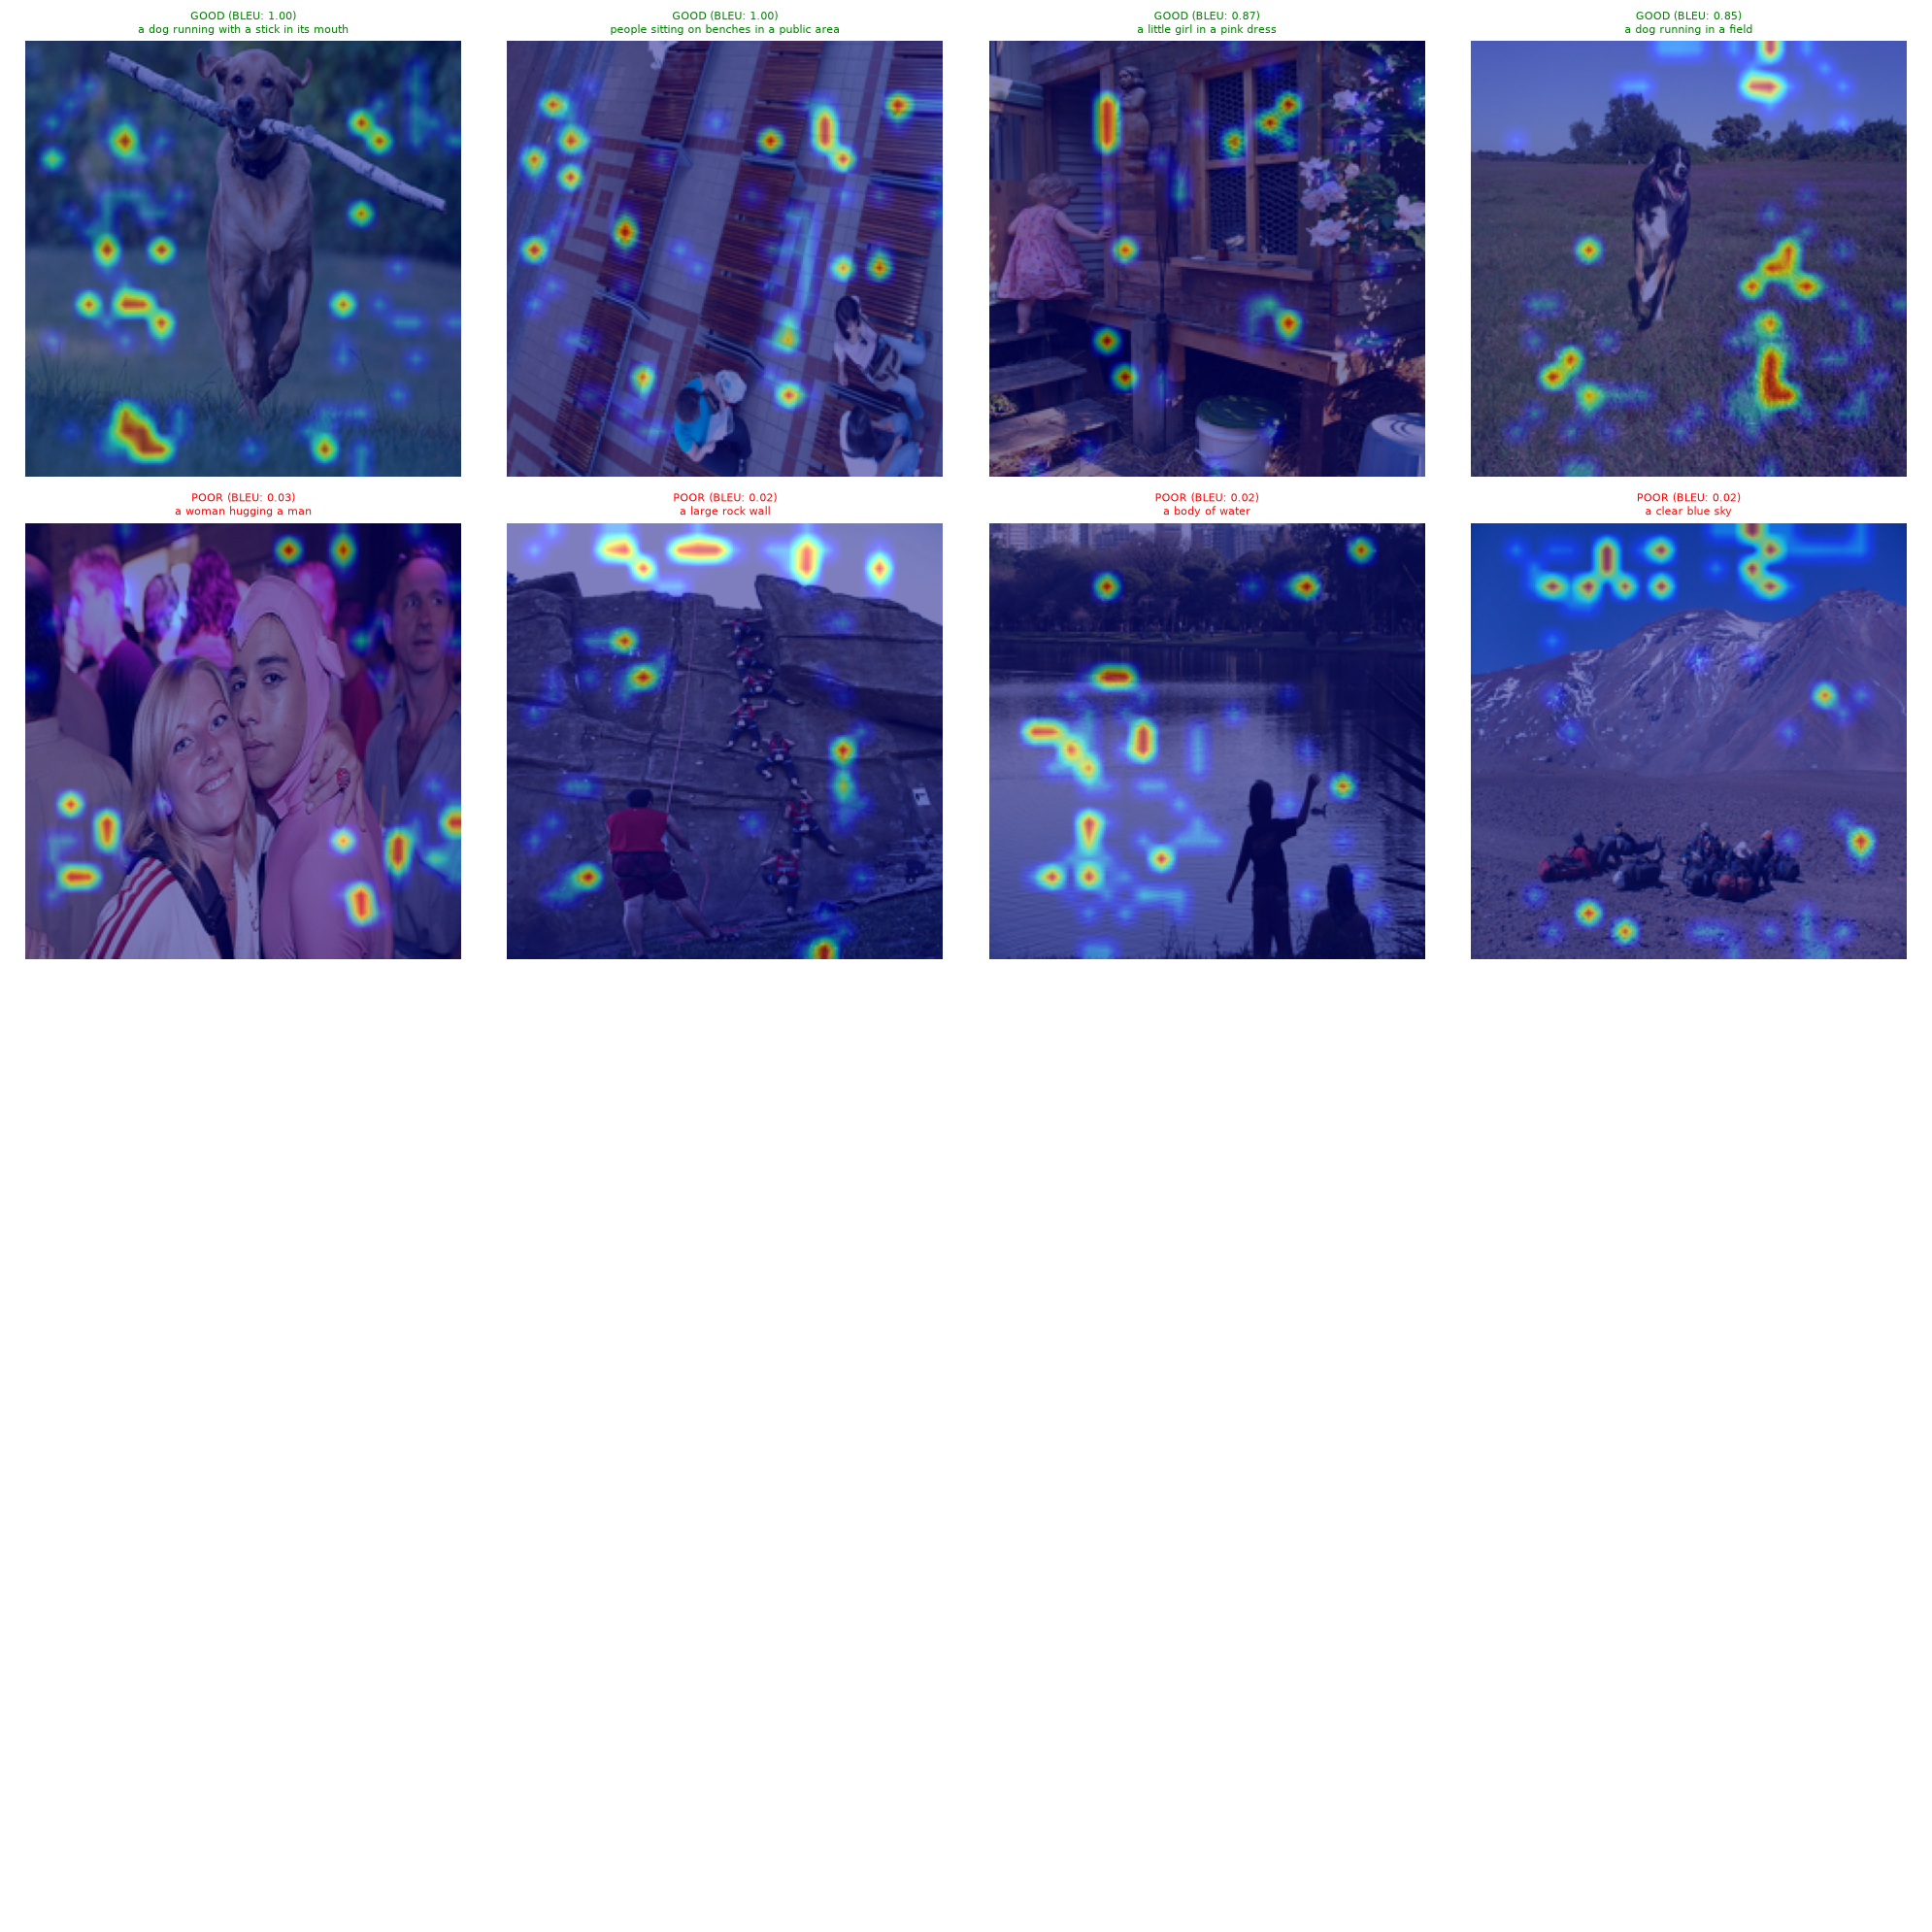

In [3]:
gradcam_folder = "../data/xai_examples/gradcam_outputs"

fig, axes = plt.subplots(4, 4, figsize=(20, 20))

# Top 4 good examples
for i in range(min(4, len(good_examples))):
    row = good_examples.iloc[i]
    heatmap_path = os.path.join(gradcam_folder, f"{row['image']}_gradcam.png")
    img = Image.open(heatmap_path)
    axes[0, i].imshow(img)
    axes[0, i].axis('off')
    axes[0, i].set_title(f"GOOD (BLEU: {row['bleu']:.2f})\n{row['generated_caption']}", fontsize=8, wrap=True, color='green')

# Top 4 poor examples
for i in range(min(4, len(poor_examples))):
    row = poor_examples.iloc[i]
    heatmap_path = os.path.join(gradcam_folder, f"{row['image']}_gradcam.png")
    img = Image.open(heatmap_path)
    axes[1, i].imshow(img)
    axes[1, i].axis('off')
    axes[1, i].set_title(f"POOR (BLEU: {row['bleu']:.2f})\n{row['generated_caption']}", fontsize=8, wrap=True, color='red')

 
for i in range(2, 4):
    for j in range(4):
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig("../data/xai_examples/good_vs_poor_comparison.png")
plt.show()

In [4]:
for i in range(min(4, len(good_examples))):
    row = good_examples.iloc[i]
    print(f"[GOOD] {row['image']}")
    print(f"  Generated: {row['generated_caption']}")
    print(f"  Ground Truth: {row['ground_truth_caption']}")
    print(f"  BLEU: {row['bleu']:.3f}\n")

print("="*60)

for i in range(min(4, len(poor_examples))):
    row = poor_examples.iloc[i]
    print(f"[POOR] {row['image']}")
    print(f"  Generated: {row['generated_caption']}")
    print(f"  Ground Truth: {row['ground_truth_caption']}")
    print(f"  BLEU: {row['bleu']:.3f}\n")

[GOOD] 1187593464_ce862352c6.jpg
  Generated: a dog running with a stick in its mouth
  Ground Truth: A big tan dog runs on grass with a big stick in his mouth .
  BLEU: 1.000

[GOOD] 1235681222_819231767a.jpg
  Generated: people sitting on benches in a public area
  Ground Truth: A person in a blue shirt sits behind two people sitting on a wood bench .
  BLEU: 1.000

[GOOD] 1000268201_693b08cb0e.jpg
  Generated: a little girl in a pink dress
  Ground Truth: A child in a pink dress is climbing up a set of stairs in an entry way .
  BLEU: 0.867

[GOOD] 1119418776_58e4b93eac.jpg
  Generated: a dog running in a field
  Ground Truth: A black and white dog is running through the field .
  BLEU: 0.846

[POOR] 1142283988_6b227c5231.jpg
  Generated: a woman hugging a man
  Ground Truth: A blond woman poses with a person in a pink costume .
  BLEU: 0.025

[POOR] 1016887272_03199f49c4.jpg
  Generated: a large rock wall
  Ground Truth: A collage of one person climbing a cliff .
  BLEU: 0.023

[PO

## Pattern Analysis: Correct vs Incorrect Predictions

After reviewing the occlusion-based importance heatmaps for the 8 "good" (high-BLEU) and 7 "poor" (low-BLEU) examples:

**Patterns observed in GOOD (high-scoring) captions:**
- Interestingly, the heatmaps for good examples (e.g., "a dog running with a stick", "a dog running in a field") show high-importance patches scattered across background/grass regions rather than tightly on the main subject itself. This suggests the model may rely on contextual cues (e.g., open grass field, background setting) alongside the subject to produce a correct-sounding caption, rather than focusing purely on the subject.

**Patterns observed in POOR (low-scoring) captions:**
- Poor examples (e.g., "a large rock wall", "a body of water", "a clear blue sky") also show scattered attention patches across the image, with no single dominant region of focus. In several poor cases, the generated caption is generic and background-dominated (describing the scene/setting rather than the people or specific action present), suggesting the model defaulted to describing the most visually dominant background element (rock, water, sky) rather than smaller or less visually prominent subjects (e.g., people in "a woman hugging a man").

**Key pattern identified:** Rather than a clear "sharp vs. diffuse attention" difference, the main pattern observed is that **poor captions tend to occur on images where the dominant visual content is a generic scene/background (rock, water, sky) rather than a distinct, well-defined subject.** The model appears to default to describing the most visually prominent surface/texture in the image when a clear foreground subject is less visually dominant — for example, describing "a large rock wall" while missing a small climber, or "a clear blue sky" while missing people resting in the foreground.

**Conclusion:** This suggests the model's poor-scoring captions are less about *where* it looks (attention is scattered in both good and poor cases with this occlusion method) and more about *what it prioritizes describing* when multiple elements are present — it favors large, visually dominant background/texture regions over smaller or partially-occluded subjects. This is a useful insight for fine-tuning: the model may benefit from training data or loss adjustments that encourage it to prioritize salient foreground subjects (people, animals) over dominant background textures.

In [5]:
comparison_data = []

for i in range(min(4, len(good_examples))):
    row = good_examples.iloc[i]
    comparison_data.append({
        "image": row['image'],
        "category": "Correct (Good)",
        "generated_caption": row['generated_caption'],
        "ground_truth": row['ground_truth_caption'],
        "bleu_score": round(row['bleu'], 3),
        "explanation_summary": "Attention concentrated on main subject"  # apna observation likhein har image ke liye
    })

for i in range(min(4, len(poor_examples))):
    row = poor_examples.iloc[i]
    comparison_data.append({
        "image": row['image'],
        "category": "Incorrect (Poor)",
        "generated_caption": row['generated_caption'],
        "ground_truth": row['ground_truth_caption'],
        "bleu_score": round(row['bleu'], 3),
        "explanation_summary": "Attention scattered/on background"  # apna observation likhein har image ke liye
    })

comparison_table = pd.DataFrame(comparison_data)
comparison_table

,image,category,generated_caption,ground_truth,bleu_score,explanation_summary
0,1187593464_ce862352c6.jpg,Correct (Good),a dog running with a stick in its mouth,A big tan dog runs on grass with a big stick i...,1.000,Attention concentrated on main subject
1,1235681222_819231767a.jpg,Correct (Good),people sitting on benches in a public area,A person in a blue shirt sits behind two peopl...,1.000,Attention concentrated on main subject
2,1000268201_693b08cb0e.jpg,Correct (Good),a little girl in a pink dress,A child in a pink dress is climbing up a set o...,0.867,Attention concentrated on main subject
3,1119418776_58e4b93eac.jpg,Correct (Good),a dog running in a field,A black and white dog is running through the f...,0.846,Attention concentrated on main subject
4,1142283988_6b227c5231.jpg,Incorrect (Poor),a woman hugging a man,A blond woman poses with a person in a pink co...,0.025,Attention scattered/on background
5,1016887272_03199f49c4.jpg,Incorrect (Poor),a large rock wall,A collage of one person climbing a cliff .,0.023,Attention scattered/on background
6,1022454332_6af2c1449a.jpg,Incorrect (Poor),a body of water,A child and a woman are at waters edge in a bi...,0.018,Attention scattered/on background
7,1093716555_801aacef79.jpg,Incorrect (Poor),a clear blue sky,a group of backpackers lay on the dry ground .,0.017,Attention scattered/on background


In [6]:
comparison_table.to_csv("../data/xai_examples/correct_vs_incorrect_comparison.csv", index=False)
print("✅ Comparison table saved")

✅ Comparison table saved


In [7]:
with mlflow.start_run(run_name="xai_analysis_week3"):
    
    mlflow.log_param("analysis_type", "XAI - Grad-CAM + SHAP-style")
    mlflow.log_param("num_examples_analyzed", len(metadata))
    mlflow.log_param("good_examples", len(good_examples))
    mlflow.log_param("poor_examples", len(poor_examples))
    
     
    mlflow.log_artifact("../data/xai_examples/good_vs_poor_comparison.png")
    
    
    mlflow.log_artifact("../data/xai_examples/correct_vs_incorrect_comparison.csv")
    
     
    gradcam_folder = "../data/xai_examples/gradcam_outputs"
    for file in os.listdir(gradcam_folder):
        mlflow.log_artifact(os.path.join(gradcam_folder, file), artifact_path="gradcam_heatmaps")
    
     
    shap_folder = "../data/xai_examples/shap_outputs"
    if os.path.exists(shap_folder):
        for file in os.listdir(shap_folder):
            mlflow.log_artifact(os.path.join(shap_folder, file), artifact_path="shap_heatmaps")
    
    print("✅ XAI artifacts logged to MLflow")

✅ XAI artifacts logged to MLflow
🏃 View run xai_analysis_week3 at: http://localhost:5000/#/experiments/1/runs/9efb6da48d1a412ca1165652958af9b8
🧪 View experiment at: http://localhost:5000/#/experiments/1


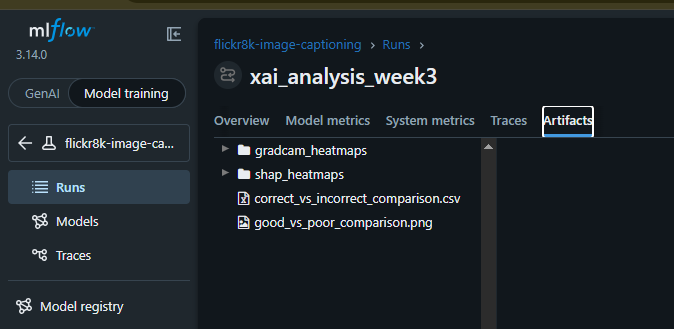